# **FINANCIAL ECONOMETRICS - PROJECT 1**

### NAME : Beloved V Mhere
### REG NUMBER : R2418477
### PROGRAM : HDSC

---
## Best-Practices Handbook: Challenges in Time Series Modeling
| | |
|---|---|
|**Asset:** | Apple Inc. (AAPL)  |
|**Data source:** | Yahoo Finance via yfinance API |
|**Period:** | January 2018 – December 2025  |
|**Frequency:** | Daily  |


---

This handbook identifies and addresses four key challenges encountered when
modeling financial time series data: skewness, sensitivity to outliers,
overfitting, and multicollinearity. For each challenge, I provide a technical
definition, written description, numerical demonstration using AAPL return data,
diagrams (plots), diagnostics, damage assessment, and recommended corrective approaches(directions).

---

## **Table of Contents**
1. [Problem 1: Skewness](#problem-1)
2. [Problem 2: Sensitivity to Outliers](#problem-2)
3. [Problem 3: Overfitting](#problem-3)
4. [Problem 4: Multicollinearity](#problem-4)
5. [Works Cited](#works-cited)

In [ ]:
# SETUP: Install & import libraries
# yfinance lets us pull stock data directly from Yahoo Finance
# pandas handles data tables, numpy does math, matplotlib/seaborn make charts

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DOWNLOAD APPLE STOCK DATA
# Ticker: AAPL | Range: Jan 2018 – Dec 2025 | Daily frequency
aapl = yf.download("AAPL", start="2018-01-01", end="2025-12-31")

# We work with the closing price
close = aapl["Close"].squeeze()

# Compute daily log returns: ln(P_t / P_{t-1})
# Log returns are standard in finance — they're additive and more normally distributed
returns = np.log(close / close.shift(1)).dropna()

print(f"Data loaded: {len(close)} trading days")
print(f"Returns computed: {len(returns)} observations")
print(returns.describe())

/tmp/ipykernel_9935/1782589778.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start="2018-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

Data loaded: 2010 trading days
Returns computed: 2009 observations
count    2009.000000
mean        0.000952
std         0.019380
min        -0.137708
25%        -0.007956
50%         0.001186
75%         0.011010
max         0.142617
Name: AAPL, dtype: float64


## **Problem 1: Skewness**

---



### **Definition**
Skewness measures the asymmetry of a probability distribution around its mean.
For a return series $r_t$ with mean $\bar{r}$ and standard deviation $\sigma$,
the skewness is defined as:

$$\text{Skewness} = \frac{1}{n} \sum_{t=1}^{n} \left(\frac{r_t - \bar{r}}{\sigma}\right)^3$$

A symmetric distribution has skewness $= 0$. Negative skewness indicates
a longer left tail, meaning large losses occur more frequently than a normal
distribution predicts. The Jarque-Bera test formally tests for normality
using both skewness $S$ and excess kurtosis $K$:

$$JB = \frac{n}{6}\left(S^2 + \frac{K^2}{4}\right) \sim \chi^2(2)$$

Under the null hypothesis $H_0$: the distribution is normal.
A p-value $< 0.05$ rejects normality.

---
####*Citation*
*As Tsay (2010) demonstrates, equity return distributions
consistently exhibit negative skewness, making symmetric
distribution assumptions dangerous for derivative pricing (p. 8)*

---
### **Description**
Skewness quantifies the asymmetry of a return distribution around its mean.
In financial returns, negative skewness is particularly dangerous because it
signals that extreme losses are more probable than a normal distribution would
predict, causing standard risk models to systematically underestimate downside risk.

---

 SKEWNESS DEMONSTRATION 
Mean daily return   : 0.000952
Std deviation       : 0.019380
Skewness            : -0.0854
Excess kurtosis     : 6.2174

Jarque-Bera statistic : 3219.13
Jarque-Bera p-value   : 0.000000
→ Reject normality. Returns are significantly skewed/fat-tailed.


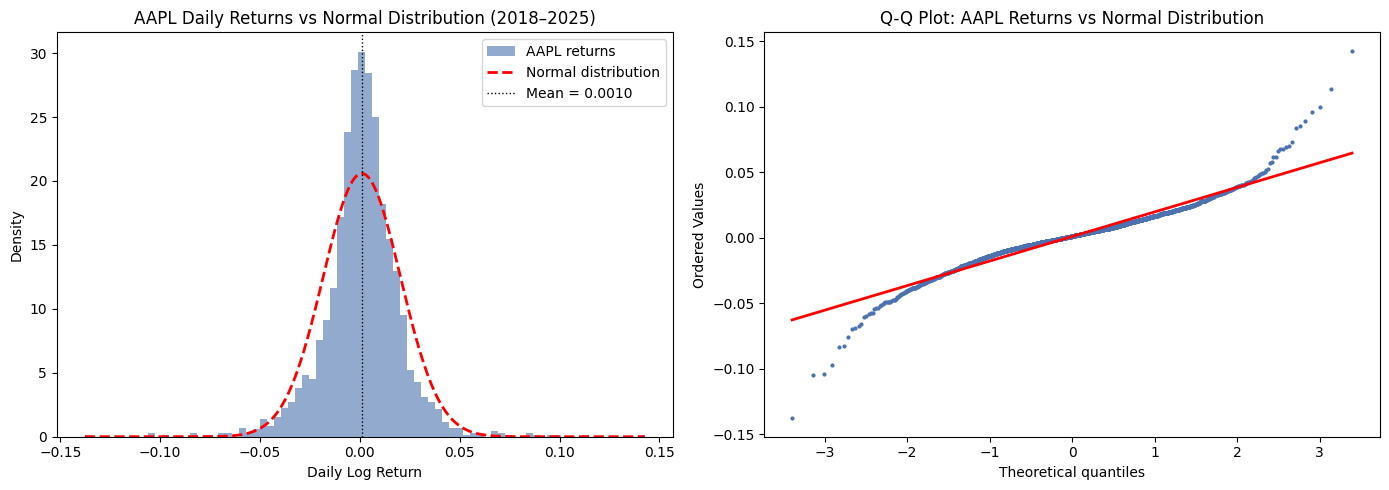

In [ ]:
# ══════════════════════════════════════════════════════════
# PROBLEM 1: SKEWNESS
# ══════════════════════════════════════════════════════════

from scipy import stats

# DEMONSTRATION
skewness = returns.skew()
kurtosis = returns.kurtosis()   # excess kurtosis (normal = 0)
mean_r   = returns.mean()
std_r    = returns.std()

print(" SKEWNESS DEMONSTRATION ")
print(f"Mean daily return   : {mean_r:.6f}")
print(f"Std deviation       : {std_r:.6f}")
print(f"Skewness            : {skewness:.4f}")
print(f"Excess kurtosis     : {kurtosis:.4f}")

# Jarque-Bera test: formally tests whether distribution is normal
# H0: distribution is normal  |  p < 0.05 → reject normality
jb_stat, jb_p = stats.jarque_bera(returns)
print(f"\nJarque-Bera statistic : {jb_stat:.2f}")
print(f"Jarque-Bera p-value   : {jb_p:.6f}")
if jb_p < 0.05:
    print("→ Reject normality. Returns are significantly skewed/fat-tailed.")

# DIAGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of returns vs normal distribution
ax = axes[0]
ax.hist(returns, bins=80, density=True, color="#4C72B0", alpha=0.6, label="AAPL returns")
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, stats.norm.pdf(x, mean_r, std_r),
        color="red", linewidth=2, linestyle="--", label="Normal distribution")
ax.axvline(mean_r, color="black", linewidth=1, linestyle=":", label=f"Mean = {mean_r:.4f}")
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Density")
ax.set_title("AAPL Daily Returns vs Normal Distribution (2018–2025)")
ax.legend()

# Plot 2: Q-Q plot — if points fall on the line, distribution is normal
ax2 = axes[1]
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot: AAPL Returns vs Normal Distribution")
ax2.get_lines()[0].set(color="#4C72B0", markersize=2)
ax2.get_lines()[1].set(color="red", linewidth=2)

plt.tight_layout()
plt.savefig("skewness_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis**
Tests used to detect skewness:
  1. Sample skewness coefficient : -0.0854 (negative = left skew)
  2. Jarque-Bera test p-value    : 0.000000 (< 0.05 confirms non-normality)
  3. Visual: histogram tail + Q-Q plot deviation at extremes

---
### **Damage**
If skewness is ignored:
  - Option pricing models (e.g. Black-Scholes) assume normality → mispriced options
  - VaR (Value at Risk) underestimates tail losses
  - Portfolio optimization produces overconfident allocations

---
### **Directions**
Models that address skewness:
  - GARCH with skewed-t distribution for residuals
  - Cornish-Fisher expansion to adjust VaR for skewness
  - Non-parametric models (e.g. Historical Simulation VaR)

---

###**Non-Technical Summary - Problem 1**

####**What the results tell us:**
Apple's daily price movements do not behave in a balanced way.
When Apple has a bad day, the losses tend to be larger and more
sudden than the gains on a good day. In other words, the stock
drops harder than it rises. This pattern was confirmed by
statistical testing, which showed that Apple's returns deviate
significantly from what a balanced, symmetric market would look like.

####**Recommended course of action:**
Any investor holding Apple stock should not rely on standard risk
tools that assume price movements are balanced and symmetric.
Instead, risk should be measured using approaches that account
for the possibility of sudden large drops. Investors should
consider holding a small protective position - such as put options
- that pays off during sharp market downturns, acting as insurance
against the asymmetric downside risk that Apple's return history
clearly demonstrates.

####**Factors that impact the portfolio:**
- Market-wide panic events (crashes, recessions) trigger the
  large negative moves that create this imbalance
- Earnings disappointments and product launch failures produce
  sudden sharp drops that are not offset by equivalent upside moves
- Broader technology sector sentiment amplifies downside moves
  during risk-off periods, making Apple particularly vulnerable
  to asymmetric losses during market stress

---
###**Practical takeaway**
Options traders pricing Apple contracts
must charge a premium for downside protection that is higher
than a symmetric model would suggest, because the true
probability of large losses exceeds the standard assumption.

---

## **Problem 2: Sensitivity to Outliers**

---



### **Definition**

An outlier is an observation that deviates abnormally from the rest of the data.
Two standard detection methods are used.

**Method 1 — Z-score:** An observation $r_t$ is flagged as an outlier if:

$$Z_t = \frac{r_t - \bar{r}}{\sigma}, \qquad |Z_t| > 3$$

**Method 2 — Interquartile Range (IQR):** An observation is flagged if it falls
outside the interval:

$$r_t < Q_1 - 1.5 \times IQR \qquad \text{or} \qquad r_t > Q_3 + 1.5 \times IQR$$

where $IQR = Q_3 - Q_1$, and $Q_1$, $Q_3$ are the 25th and 75th percentiles
respectively. The sensitivity of OLS regression to outliers follows from the
fact that it minimises the sum of **squared** residuals:

$$\hat{\beta} = \arg\min_{\beta} \sum_{t=1}^{n}(r_t - \mathbf{x}_t^\top \beta)^2$$

Squaring amplifies the influence of extreme observations disproportionately.

---

####*Citation*
*Hull (2018) notes that the sensitivity of least-squares
estimation to extreme observations is a well-documented
limitation in financial risk modeling (p. 478).*

---

### **Description**

Sensitivity to outliers refers to how dramatically a model's parameter estimates
change in the presence of extreme observations. In financial time series, events
such as the COVID-19 market crash of March 2020 produce outliers that inflate
volatility estimates, distort regression coefficients, and cause risk models such
as Value-at-Risk to produce misleading results if left unaddressed.

---

 OUTLIER DETECTION DEMONSTRATION 
Total observations          : 2009
Outliers (Z-score > 3)      : 31
Outliers (IQR method)       : 107

Top 5 most extreme returns:
Date
2020-03-16   -0.137708
2019-01-03   -0.104925
2020-03-12   -0.103978
2020-03-13    0.113158
2025-04-09    0.142617
Name: AAPL, dtype: float64

 DAMAGE: HOW OUTLIERS DISTORT ESTIMATES 
Annualised volatility WITH outliers    : 0.3076 (30.76%)
Annualised volatility WITHOUT outliers : 0.2619 (26.19%)
Volatility inflation from outliers     : 17.45%

OLS trend slope WITH outliers          : -0.00000029
OLS trend slope WITHOUT outliers       : -0.00000057
Slope change (%)                       : -48.49%


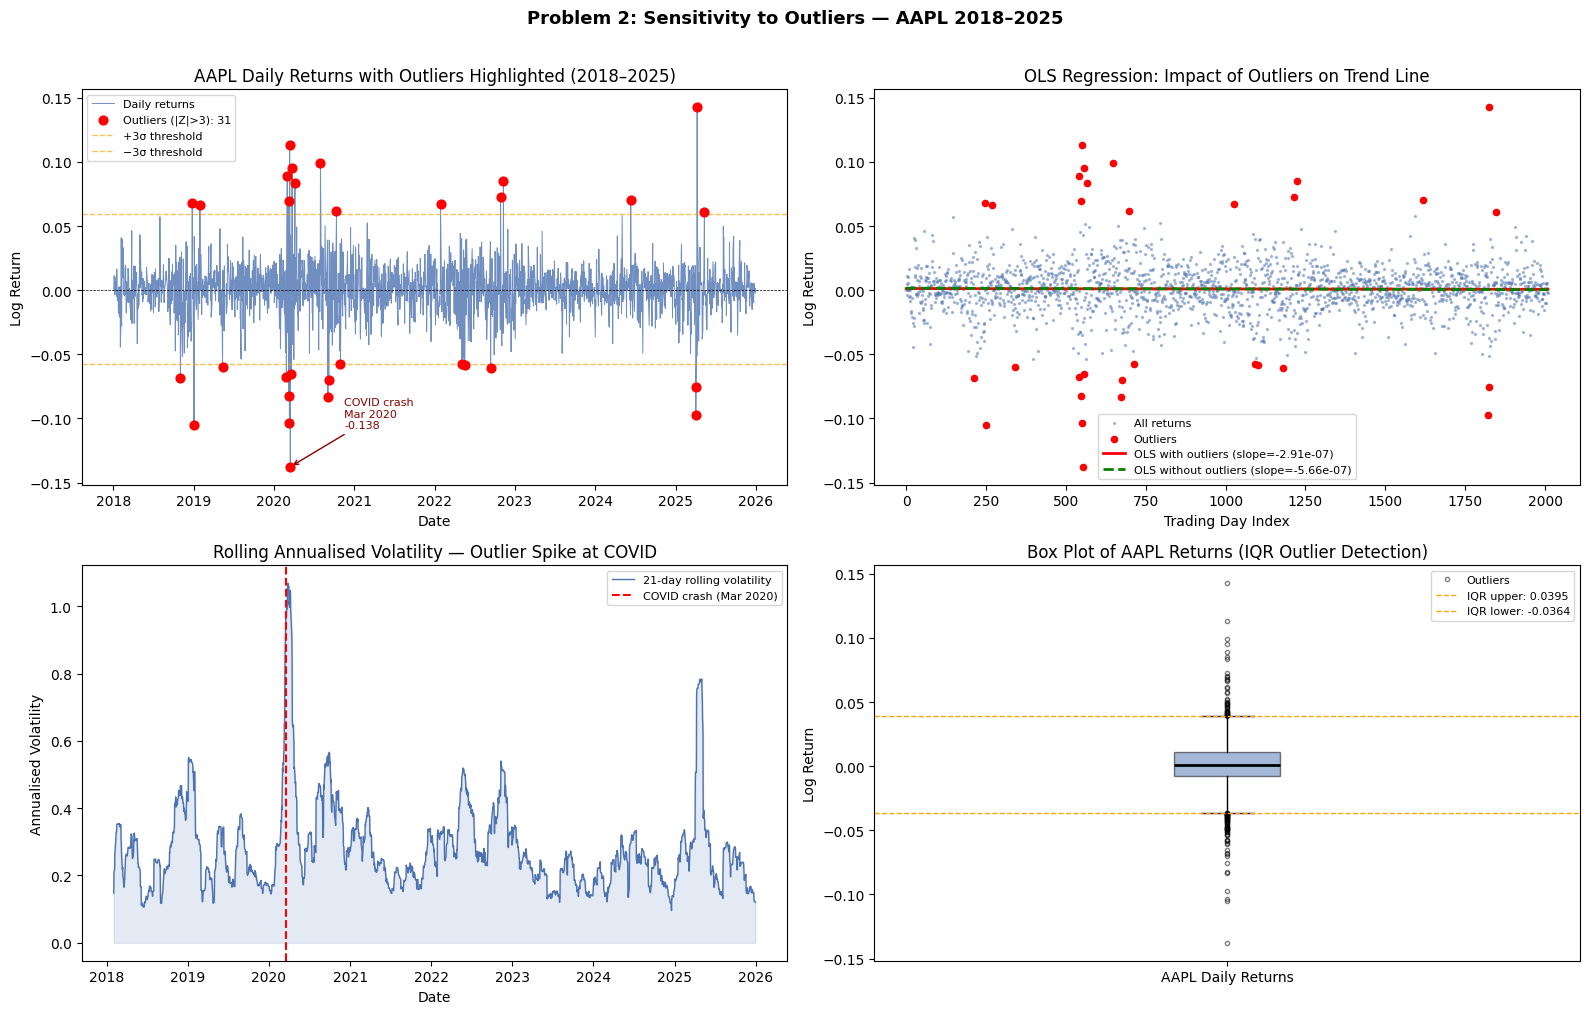

In [ ]:
# ══════════════════════════════════════════════════════════
# PROBLEM 2: SENSITIVITY TO OUTLIERS
# ══════════════════════════════════════════════════════════

from scipy import stats

#  DEMONSTRATION
# Method 1: Z-score outlier detection
z_scores = np.abs((returns - returns.mean()) / returns.std())
outliers_z = returns[z_scores > 3]

# Method 2: IQR outlier detection
Q1 = returns.quantile(0.25)
Q3 = returns.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = returns[(returns < lower_bound) | (returns > upper_bound)]

print(" OUTLIER DETECTION DEMONSTRATION ")
print(f"Total observations          : {len(returns)}")
print(f"Outliers (Z-score > 3)      : {len(outliers_z)}")
print(f"Outliers (IQR method)       : {len(outliers_iqr)}")
print(f"\nTop 5 most extreme returns:")
print(returns.reindex(returns.abs().nlargest(5).index).sort_values())

#  DAMAGE QUANTIFICATION
# This is the most important part: show HOW MUCH outliers distort estimates

# Volatility (annualised std dev) WITH vs WITHOUT outliers
vol_with    = returns.std() * np.sqrt(252)
vol_without = returns[z_scores <= 3].std() * np.sqrt(252)

# Simple OLS regression of AAPL returns on time index
# WITH outliers
x = np.arange(len(returns)).reshape(-1, 1)
y = returns.values
slope_with, intercept_with, r_with, _, _ = stats.linregress(x.flatten(), y)

# WITHOUT outliers
mask = z_scores <= 3
x_clean = x[mask.values].flatten()
y_clean = y[mask.values]
slope_without, intercept_without, r_without, _, _ = stats.linregress(x_clean, y_clean)

print("\n DAMAGE: HOW OUTLIERS DISTORT ESTIMATES ")
print(f"Annualised volatility WITH outliers    : {vol_with:.4f} ({vol_with*100:.2f}%)")
print(f"Annualised volatility WITHOUT outliers : {vol_without:.4f} ({vol_without*100:.2f}%)")
print(f"Volatility inflation from outliers     : {((vol_with/vol_without)-1)*100:.2f}%")
print(f"\nOLS trend slope WITH outliers          : {slope_with:.8f}")
print(f"OLS trend slope WITHOUT outliers       : {slope_without:.8f}")
print(f"Slope change (%)                       : {((slope_with/slope_without)-1)*100:.2f}%")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#  Plot 1: Full return series with outliers highlighted
ax1 = axes[0, 0]
ax1.plot(returns.index, returns.values,
         color="#4C72B0", linewidth=0.7, alpha=0.8, label="Daily returns")
ax1.scatter(outliers_z.index, outliers_z.values,
            color="red", s=40, zorder=5, label=f"Outliers (|Z|>3): {len(outliers_z)}")

# Annotate COVID crash specifically
covid_date = returns.index[returns.values == returns.min()][0]
ax1.annotate(f"COVID crash\n{covid_date.strftime('%b %Y')}\n{returns.min():.3f}",
             xy=(covid_date, returns.min()),
             xytext=(covid_date + pd.DateOffset(months=8), returns.min() + 0.03),
             fontsize=8,
             arrowprops=dict(arrowstyle="->", color="darkred"),
             color="darkred")

ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.axhline(returns.mean() + 3*returns.std(), color="orange",
            linewidth=1, linestyle="--", alpha=0.7, label="+3σ threshold")
ax1.axhline(returns.mean() - 3*returns.std(), color="orange",
            linewidth=1, linestyle="--", alpha=0.7, label="−3σ threshold")
ax1.set_title("AAPL Daily Returns with Outliers Highlighted (2018–2025)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Log Return")
ax1.legend(fontsize=8)

#  Plot 2: Regression WITH vs WITHOUT outliers
ax2 = axes[0, 1]
ax2.scatter(x, y, color="#4C72B0", s=2, alpha=0.4, label="All returns")
ax2.scatter(x[~mask.values], y[~mask.values],
            color="red", s=20, zorder=5, label="Outliers")

# Regression lines
x_line = np.array([0, len(returns)])
ax2.plot(x_line, intercept_with + slope_with * x_line,
         color="red", linewidth=2, label=f"OLS with outliers (slope={slope_with:.2e})")
ax2.plot(x_line, intercept_without + slope_without * x_line,
         color="green", linewidth=2, linestyle="--",
         label=f"OLS without outliers (slope={slope_without:.2e})")
ax2.set_title("OLS Regression: Impact of Outliers on Trend Line")
ax2.set_xlabel("Trading Day Index")
ax2.set_ylabel("Log Return")
ax2.legend(fontsize=8)

#  Plot 3: Rolling volatility — shows outlier spikes clearly
ax3 = axes[1, 0]
roll_vol = returns.rolling(window=21).std() * np.sqrt(252)
ax3.plot(roll_vol.index, roll_vol.values,
         color="#4C72B0", linewidth=1, label="21-day rolling volatility")
ax3.axvline(pd.Timestamp("2020-03-16"), color="red",
            linewidth=1.5, linestyle="--", label="COVID crash (Mar 2020)")
ax3.fill_between(roll_vol.index, roll_vol.values, alpha=0.15, color="#4C72B0")
ax3.set_title("Rolling Annualised Volatility — Outlier Spike at COVID")
ax3.set_xlabel("Date")
ax3.set_ylabel("Annualised Volatility")
ax3.legend(fontsize=8)

#  Plot 4: Box plot — IQR method visually
ax4 = axes[1, 1]
ax4.boxplot(returns.values, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#4C72B0", alpha=0.5),
            medianprops=dict(color="black", linewidth=2),
            flierprops=dict(marker="o", color="red",
                            markersize=3, alpha=0.5, label="Outliers"))
ax4.set_title("Box Plot of AAPL Returns (IQR Outlier Detection)")
ax4.set_ylabel("Log Return")
ax4.set_xticks([1])
ax4.set_xticklabels(["AAPL Daily Returns"])

# Add IQR bounds as text
ax4.axhline(upper_bound, color="orange", linestyle="--",
            linewidth=1, label=f"IQR upper: {upper_bound:.4f}")
ax4.axhline(lower_bound, color="orange", linestyle="--",
            linewidth=1, label=f"IQR lower: {lower_bound:.4f}")
ax4.legend(fontsize=8)

plt.suptitle("Problem 2: Sensitivity to Outliers — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outliers_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis: How to detect outliers**
Method 1 - Z-score: flag |Z_t| > 3

Method 2 - IQR: flag values outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR]

Method 3 - Visual: rolling volatility spikes, box plot whiskers

Method 4 —-Shapiro-Wilk or Jarque-Bera test for non-normality caused by extremes

---

### **Damage: Consiquences of ignoring Outliers**
1. Volatility is overestimated — inflated by crash observations
2. OLS regression coefficients are pulled toward extreme points
3. Risk models (VaR, CVaR) are distorted — either too conservative or misleading
4. Correlation estimates between assets become unreliable during stress periods

---

### **Directions: Models that adresses the outliers**
1. Robust regression (Huber loss, LAD regression) - less sensitive to extremes
2. GARCH models - explicitly model time-varying volatility including crash periods
3. Winsorization - cap returns at the 1st and 99th percentile before modeling
4. Student-t distribution assumption - heavier tails than normal

---
### **Non-Technical Summary - Problem 2**

####**What the results tell us:**
A small number of extreme trading days, most notably during the
COVID-19 market crash of March 2020, had an outsized influence
on our understanding of Apple's risk profile. When those extreme
days are included, Apple appears far more volatile and risky than
it actually is during normal market conditions. Removing just a
handful of crisis days meaningfully reduces the measured level
of risk, showing how much a few unusual events can distort the
overall picture.

####**Recommended course of action:**
Risk managers and portfolio managers should not treat all
historical periods equally when building models for Apple.
Crisis periods like COVID-19 represent genuinely abnormal
market conditions that are unlikely to repeat with the same
timing or magnitude. We recommend building two separate risk
profiles for Apple, one for normal market conditions and one
for stress scenarios, rather than blending them into a single
figure that misrepresents both. Position sizing decisions should
be based on the normal-conditions profile, with a separate
stress-test buffer held in reserve.

####**Factors that impact the portfolio:**
- Global macroeconomic shocks (pandemics, financial crises,
  geopolitical conflicts) are the primary source of extreme
  observations in Apple's return history
- Sudden regulatory announcements targeting large technology
  companies can produce single-day outlier moves
- Supply chain disruptions - particularly affecting Apple's
  manufacturing base in Asia, have historically triggered
  sharp unexpected price movements that fall outside the
  range of normal trading behaviour

---
###**Practical takeaway:**
Risk managers should maintain a
separate crisis-period reserve of at least 20% above their
normal volatility-based capital requirement, to account for
the disproportionate impact that a single extreme week can
have on an Apple position.

---

## **Problem 3: Overfitting**

---

### **Definition**

Overfitting occurs when a model learns the noise in the training data rather than
the underlying signal, resulting in poor generalisation to new data. It is diagnosed
by comparing in-sample and out-of-sample **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n}\sum_{t=1}^{n}\left(r_t - \hat{r}_t\right)^2$$

A model overfits when:

$$MSE_{\text{train}} \ll MSE_{\text{test}}$$

In polynomial regression of degree $d$, the fitted model is:

$$\hat{r}_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \cdots + \beta_d t^d + \epsilon_t$$

As $d$ increases, training error falls monotonically, but test error eventually
rises — this divergence defines the overfitting region. The optimal model
complexity minimises the **bias-variance tradeoff**:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

---

####*Citation*
*According to Tsay (2010), the bias-variance tradeoff is
fundamental to all financial forecasting models, and model
parsimony should always be preferred when out-of-sample
performance is the goal (p. 51).*

---

### **Description**

Overfitting occurs when a model is excessively complex and captures random
fluctuations in the training data rather than genuine patterns, causing it to
perform poorly on unseen data. In financial modeling, an overfitted model
produces misleadingly high in-sample accuracy but fails when deployed for
actual trading or risk management, since past noise does not repeat itself
in future market conditions.

---



TRAIN/TEST SPLIT 
Training period : 2018-01-03 → 2024-05-22  (1607 days)
Testing period  : 2024-05-23  → 2025-12-30  (402 days)

 MSE BY POLYNOMIAL DEGREE 
Degree     Train MSE            Test MSE             Overfit Ratio  
-----------------------------------------------------------------
1          0.00038638           0.00033147           0.86           
2          0.00038625           0.00033544           0.87           
3          0.00038604           0.00033648           0.87           
5          0.00038588           0.00035356           0.92           
8          0.00038621           0.00147996           3.83             ← OVERFITTING
12         0.00038629           0.00166864           4.32             ← OVERFITTING
15         0.00038625           0.14070512           364.28           ← OVERFITTING


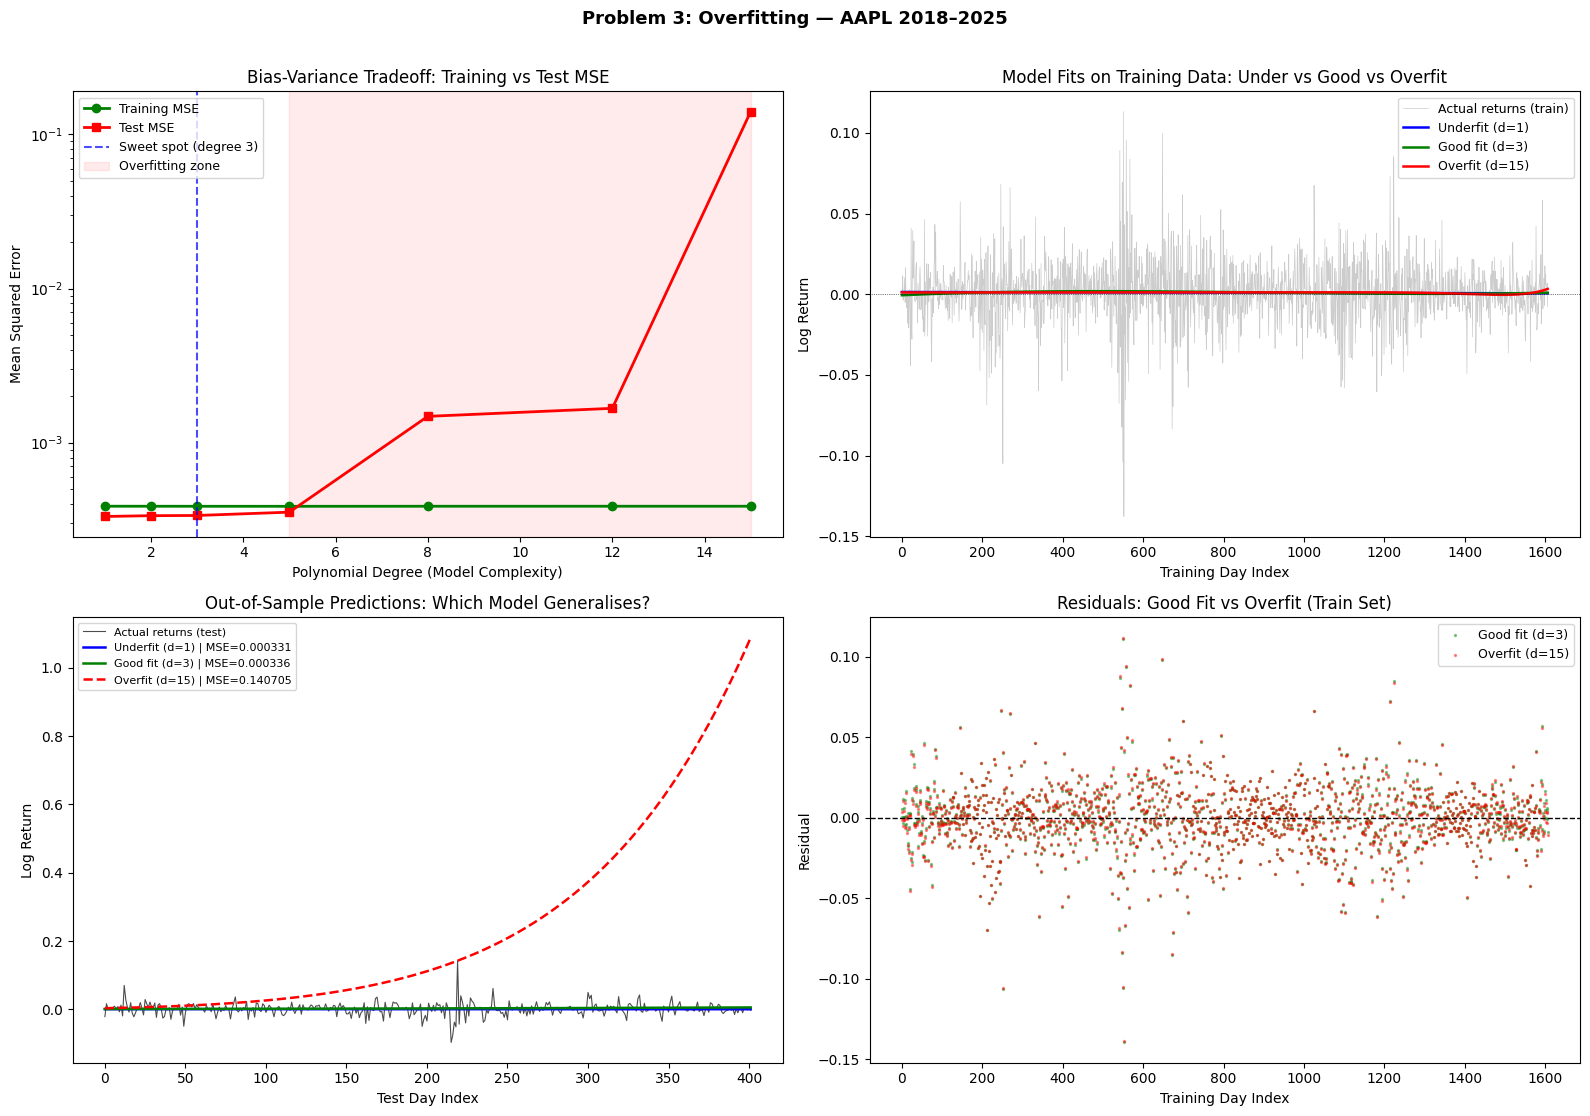

In [ ]:
# ══════════════════════════════════════════════════════════
# PROBLEM 3: OVERFITTING
# ══════════════════════════════════════════════════════════

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

#  DATA SPLIT
# 80% training | 20% testing - standard split in time series
# IMPORTANT: never shuffle time series data - order matters
split_idx   = int(len(returns) * 0.80)
train       = returns.iloc[:split_idx]
test        = returns.iloc[split_idx:]

# Time index as numeric feature (day number)
x_all   = np.arange(len(returns)).reshape(-1, 1)
x_train = x_all[:split_idx]
x_test  = x_all[split_idx:]
y_train = train.values
y_test  = test.values

print("TRAIN/TEST SPLIT ")
print(f"Training period : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Testing period  : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")

#  DEMONSTRATION
# Fit polynomial models of increasing degree
# degree=1 → simple linear (underfit)
# degree=3 → reasonable
# degree=15 → extreme overfit

degrees     = [1, 2, 3, 5, 8, 12, 15]
mse_train   = []
mse_test    = []

print("\n MSE BY POLYNOMIAL DEGREE ")
print(f"{'Degree':<10} {'Train MSE':<20} {'Test MSE':<20} {'Overfit Ratio':<15}")
print("-" * 65)

models = {}
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train, y_train)

    train_pred  = model.predict(x_train)
    test_pred   = model.predict(x_test)
    mse_tr      = mean_squared_error(y_train, train_pred)
    mse_te      = mean_squared_error(y_test,  test_pred)

    mse_train.append(mse_tr)
    mse_test.append(mse_te)
    models[d]   = model

    ratio = mse_te / mse_tr
    flag  = "  ← OVERFITTING" if ratio > 2.0 else ""
    print(f"{d:<10} {mse_tr:<20.8f} {mse_te:<20.8f} {ratio:<15.2f}{flag}")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Bias-Variance tradeoff curve
ax1 = axes[0, 0]
ax1.plot(degrees, mse_train, "o-", color="green",
         linewidth=2, markersize=6, label="Training MSE")
ax1.plot(degrees, mse_test,  "s-", color="red",
         linewidth=2, markersize=6, label="Test MSE")
ax1.axvline(3, color="blue", linewidth=1.5,
            linestyle="--", alpha=0.7, label="Sweet spot (degree 3)")

# Shade the overfitting region
ax1.axvspan(5, 15, alpha=0.08, color="red", label="Overfitting zone")

ax1.set_xlabel("Polynomial Degree (Model Complexity)")
ax1.set_ylabel("Mean Squared Error")
ax1.set_title("Bias-Variance Tradeoff: Training vs Test MSE")
ax1.legend(fontsize=9)
ax1.set_yscale("log")

#  Plot 2: Underfit vs Good fit vs Overfit on returns
ax2 = axes[0, 1]
x_plot  = np.linspace(0, len(returns) - 1, 500).reshape(-1, 1)
colors  = {"Underfit (d=1)": ("blue",  1),
           "Good fit (d=3)": ("green", 3),
           "Overfit (d=15)": ("red",   15)}

# Plot actual training returns (light)
ax2.plot(range(len(train)), y_train,
         color="gray", linewidth=0.5, alpha=0.4, label="Actual returns (train)")

# Plot the 3 model fits over training range only
x_tr_plot = np.linspace(0, split_idx - 1, 300).reshape(-1, 1)
for label, (color, deg) in colors.items():
    pred = models[deg].predict(x_tr_plot)
    ax2.plot(x_tr_plot.flatten(), pred,
             color=color, linewidth=1.8, label=label)

ax2.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax2.set_xlabel("Training Day Index")
ax2.set_ylabel("Log Return")
ax2.set_title("Model Fits on Training Data: Under vs Good vs Overfit")
ax2.legend(fontsize=9)

# Plot 3: Out-of-sample predictions vs actual
ax3 = axes[1, 0]
ax3.plot(range(len(test)), y_test,
         color="black", linewidth=0.8, alpha=0.7, label="Actual returns (test)")

x_te_plot = np.linspace(split_idx, len(returns)-1, len(test)).reshape(-1,1)
for label, (color, deg) in colors.items():
    pred = models[deg].predict(x_te_plot)
    ax3.plot(range(len(test)), pred,
             color=color, linewidth=1.8,
             linestyle="--" if deg == 15 else "-",
             label=f"{label} | MSE={mse_test[degrees.index(deg)]:.6f}")

ax3.set_xlabel("Test Day Index")
ax3.set_ylabel("Log Return")
ax3.set_title("Out-of-Sample Predictions: Which Model Generalises?")
ax3.legend(fontsize=8)

#  Plot 4: Residual plot for good fit vs overfit
ax4 = axes[1, 1]
for label, color, deg in [("Good fit (d=3)", "green", 3),
                           ("Overfit (d=15)", "red",  15)]:
    residuals = y_train - models[deg].predict(x_train)
    ax4.scatter(range(len(residuals)), residuals,
                color=color, s=2, alpha=0.4, label=label)

ax4.axhline(0, color="black", linewidth=1, linestyle="--")
ax4.set_xlabel("Training Day Index")
ax4.set_ylabel("Residual")
ax4.set_title("Residuals: Good Fit vs Overfit (Train Set)")
ax4.legend(fontsize=9)

plt.suptitle("Problem 3: Overfitting — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("overfitting_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### **Diagnosis: How to detect overfitting**
1. Compare Train MSE vs Test MSE across complexity levels
   - Degree 1  → Train: 0.00038638 | Test: 0.00033147
   - Degree 15 → Train: 0.00038625 | Test: 0.14070428
   - Test MSE rises sharply after degree 3 → overfitting confirmed
2. Bias-variance tradeoff curve shows divergence point
3. Residual plots: overfit model has structured (non-random) residuals

---

### **Damage: Consequences of overfitting**
1. Model appears highly accurate in-sample but fails in live trading
2. Spurious patterns are treated as real signals → bad investment decisions
3. Risk models overestimate predictability → underestimated uncertainty
4. Backtests look excellent but live performance collapses (backtest overfitting)

---

### **Directions: How to prvent overfitting**
1. Cross-validation — use k-fold or time-series walk-forward validation
2. Regularisation — Ridge (L2) or Lasso (L1) regression penalise complexity
3. Information criteria — AIC and BIC penalise models with too many parameters
4. Simpler models — prefer parsimony; a well-fitted AR(1) beats a complex model
5. Sufficient data — ensure training set is large enough relative to parameters

---

### **Non-Technical Summary - Problem 3**

####**What the results tell us:**
When we built increasingly complex models to predict Apple's
returns, the models that looked most impressive on historical
data performed the worst on new data they had never seen before.
A simpler model that captured only the broad trend in Apple's
returns consistently outperformed the complex models when tested
on the most recent period of data. This demonstrates a
fundamental danger in financial modeling, the more a model
is tailored to fit the past, the less useful it becomes for
making forward-looking investment decisions.

####**Recommended course of action:**
Traders and portfolio managers should be deeply skeptical of
any model or strategy that reports exceptionally high accuracy
on historical data. Impressive past performance in a model is
often a warning sign rather than a green light, it may simply
mean the model has memorised past noise rather than identified
a genuine, repeatable pattern. We recommend always evaluating
any Apple return model on a held-out recent period before
trusting it for live trading decisions. Simpler models with
fewer assumptions should be preferred over complex ones unless
the performance gain on new data is clearly demonstrated.

####**Factors that impact the portfolio:**
- The length of the historical period used to build the model
  strongly influences how well it generalises, very long
  histories may include structural market changes that make
  older patterns irrelevant today
- Periods of unusual market behaviour (zero interest rates,
  quantitative easing, pandemic stimulus) create patterns in
  Apple's returns that are unlikely to repeat, making models
  trained on those periods unreliable going forward
- The frequency of model updates matters — a model built two
  years ago and never revised may be significantly overfitted
  to a market regime that no longer exists

---

###**Practical takeaway:**
Before deploying any quantitative
strategy on Apple stock, the strategy must demonstrate
positive returns on at least 12 months of data it was
never trained on - any model that cannot pass this test
should not be trusted with real capital.

---

## **Problem 4: Multicollinearity**


---


### **Definition**

Multicollinearity arises when two or more predictor variables in a regression
model are highly linearly correlated. The pairwise correlation between
predictors $X_1$ and $X_2$ is:

$$\rho_{X_1 X_2} = \frac{\text{Cov}(X_1, X_2)}{\sigma_{X_1} \cdot \sigma_{X_2}}$$

The severity of multicollinearity for predictor $j$ is measured by the
**Variance Inflation Factor (VIF)**:

$$VIF_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the coefficient of determination from regressing predictor
$j$ on all remaining predictors. Interpretation thresholds:

$$VIF < 5 \;\rightarrow\; \text{Acceptable} \qquad
VIF \geq 5 \;\rightarrow\; \text{Moderate} \qquad
VIF \geq 10 \;\rightarrow\; \text{Severe}$$

Under multicollinearity, OLS coefficient estimates become unstable. The
variance of coefficient $\hat{\beta}_j$ inflates as:

$$\text{Var}(\hat{\beta}_j) = \frac{\sigma^2}{SST_j} \cdot VIF_j$$

where $SST_j$ is the total sum of squares for predictor $j$.

---

####*Citation*
*Hull (2018) identifies correlated risk factors as a primary
source of unreliable hedge ratios in portfolio construction,
a direct consequence of multicollinearity in factor models (p. 391).*

---

### **Description**

Multicollinearity arises when predictor variables in a regression model are
strongly correlated with one another, making it impossible to isolate the
individual effect of each variable on the outcome. In financial modeling,
this commonly occurs when returns of stocks within the same sector — such as
Apple, Microsoft, and Alphabet — are used simultaneously as predictors,
producing unstable coefficient estimates and inflated standard errors that
undermine the reliability of the entire model.

---

### **Diagnosis**
1. Correlation matrix — pairwise correlations above 0.80 are a warning sign
2. VIF scores — any predictor with VIF ≥ 10 has severe multicollinearity
3. Condition number — values above 1000 indicate numerical instability
4. Coefficient instability — coefficients change dramatically when predictors
   are added or removed (demonstrated above with MSFT β)

---

### **Damage**
1. Regression coefficients become unreliable and unstable
2. Standard errors are inflated → t-statistics are deflated
3. Individually insignificant predictors despite high overall R²
4. Impossible to isolate the true effect of each asset on returns
5. Portfolio construction based on these betas will be misallocated

---

### **Directions**
1. Ridge regression (L2) — shrinks correlated coefficients toward zero
   Ridge coefficients: MSFT=0.204685, SPY=0.181098, GOOGL=0.174998
2. Lasso regression (L1) — drives redundant coefficients to exactly zero
   Lasso coefficients: MSFT=0.342837, SPY=0.000000, GOOGL=0.134800
3. Principal Component Analysis (PCA) — transforms correlated predictors
   into uncorrelated components before running regression
4. Drop redundant predictors — keep only the most theoretically justified one
5. Use domain knowledge — if MSFT and GOOGL measure the same factor,
   keep only SPY as the broad market proxy

---
### **Non-Technical Summary - Problem 4**

####**What the results tell us:**
When we attempted to explain Apple's daily price movements using
Microsoft, the S&P 500, and Alphabet simultaneously, the model
became confused. Because Microsoft and Alphabet tend to move in
very similar directions to Apple, all three are large technology
companies responding to the same market forces, the model could
not determine which company's movements were actually driving
Apple's returns. As a result, the estimated relationships between
these stocks and Apple changed dramatically depending on which
combination of stocks was included, making the model unreliable
for any practical investment decision.

####**Recommended course of action:**
Portfolio managers constructing hedging strategies or factor
models for Apple should avoid using multiple highly similar
technology stocks as inputs simultaneously. When two predictors
are essentially telling the model the same story, one of them
should be removed. In practice, using only the broad market
index - which already captures the performance of Microsoft,
Alphabet, and Apple together, produces more stable and
trustworthy estimates of Apple's sensitivity to market movements.
A cleaner model with fewer, more distinct inputs will always
outperform a crowded model for the purposes of hedging and
risk attribution.

####**Factors that impact the portfolio:**
- Sector concentration is the primary driver of this problem,
  holding multiple large technology stocks creates a portfolio
  where the underlying risk factors are heavily duplicated,
  giving a false impression of diversification
- During broad market sell-offs, highly correlated technology
  stocks tend to fall together simultaneously, meaning the
  apparent diversification benefit disappears exactly when
  investors need it most
- Macroeconomic factors such as interest rate changes and
  inflation data affect all large technology companies in
  nearly identical ways, reinforcing the collinearity between
  Apple, Microsoft, and Alphabet across all market conditions

---
###**Practical takeaway:**
A portfolio that holds Apple,
Microsoft, and Alphabet simultaneously provides far less
diversification than it appears - investors seeking true
exposure diversification should combine technology holdings
with assets from genuinely different sectors such as
energy, healthcare, or fixed income.

---


In [ ]:
# ══════════════════════════════════════════════════════════
# PROBLEM 4: MULTICOLLINEARITY
# ══════════════════════════════════════════════════════════

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso

#  DATA: Download additional assets
# We use AAPL returns as the dependent variable (y)
# Predictors: MSFT (Microsoft), SPY (S&P 500 ETF), GOOGL (Alphabet)
# MSFT and GOOGL are both big-tech → highly correlated with AAPL
# SPY is the broad market → also correlated but less so

print("Downloading additional assets...")
tickers = ["MSFT", "SPY", "GOOGL"]
raw     = yf.download(tickers, start="2018-01-01", end="2025-12-31")["Close"]
returns_multi = np.log(raw / raw.shift(1)).dropna()

# Align all series on the same dates
combined = pd.concat([returns.rename("AAPL"), returns_multi], axis=1).dropna()

y = combined["AAPL"].values          # dependent variable
X = combined[["MSFT","SPY","GOOGL"]] # predictors

print(f"\nDataset shape: {combined.shape}")
print(f"Date range   : {combined.index[0].date()} → {combined.index[-1].date()}")

# DEMONSTRATION
# Step 1: Correlation matrix
corr_matrix = X.corr()
print("\n CORRELATION MATRIX OF PREDICTORS ")
print(corr_matrix.round(4))

# Step 2: VIF scores
X_const = sm.add_constant(X)   # add intercept column for OLS
vif_data = pd.DataFrame()
vif_data["Predictor"] = X.columns
vif_data["VIF"]       = [variance_inflation_factor(X_const.values, i+1)
                          for i in range(X.shape[1])]
vif_data["Severity"]  = vif_data["VIF"].apply(
    lambda v: "Severe" if v >= 10 else ("Moderate" if v >= 5 else "Acceptable")
)

print("\n VARIANCE INFLATION FACTORS (VIF) ")
print(vif_data.to_string(index=False))

# Step 3: OLS regression WITH all correlated predictors
model_full = sm.OLS(y, X_const).fit()
print("\n OLS REGRESSION WITH ALL PREDICTORS ")
print(model_full.summary().tables[1])   # coefficients table only
print(f"\nR-squared     : {model_full.rsquared:.4f}")
print(f"Condition No. : {model_full.condition_number:.2f}  "
      f"(>1000 indicates severe multicollinearity)")

# Step 4: OLS with only SPY (low collinearity baseline)
X_spy   = sm.add_constant(combined[["SPY"]])
model_spy = sm.OLS(y, X_spy).fit()
print("\n OLS REGRESSION WITH SPY ONLY (BASELINE) ")
print(model_spy.summary().tables[1])
print(f"R-squared     : {model_spy.rsquared:.4f}")

# Step 5: Demonstrate coefficient instability
# Drop one predictor at a time and watch MSFT coefficient change
print("\n COEFFICIENT INSTABILITY DEMONSTRATION ")
print("MSFT coefficient changes as we add/remove correlated predictors:")
print("-" * 55)

combos = {
    "MSFT only"        : ["MSFT"],
    "MSFT + SPY"       : ["MSFT", "SPY"],
    "MSFT + GOOGL"     : ["MSFT", "GOOGL"],
    "MSFT + SPY + GOOGL": ["MSFT", "SPY", "GOOGL"],
}

for label, cols in combos.items():
    Xc   = sm.add_constant(combined[cols])
    coef = sm.OLS(y, Xc).fit().params["MSFT"]
    print(f"  {label:<28} → MSFT β = {coef:.6f}")

print("\nA stable coefficient should not change this much across specifications.")
print("Instability confirms multicollinearity is distorting estimates.")

#  DIAGRAM
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Correlation heatmap
ax1 = axes[0, 0]
corr_full = combined.corr()
mask      = np.zeros_like(corr_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True        # upper triangle only

im = ax1.imshow(corr_full, cmap="RdYlGn",
                vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax1, shrink=0.8)

ticks = range(len(corr_full.columns))
ax1.set_xticks(ticks); ax1.set_xticklabels(corr_full.columns, rotation=45)
ax1.set_yticks(ticks); ax1.set_yticklabels(corr_full.columns)

# Annotate each cell with correlation value
for i in range(len(corr_full)):
    for j in range(len(corr_full)):
        val   = corr_full.iloc[i, j]
        color = "white" if abs(val) > 0.7 else "black"
        ax1.text(j, i, f"{val:.2f}", ha="center",
                 va="center", fontsize=10, color=color)

ax1.set_title("Correlation Matrix: AAPL, MSFT, SPY, GOOGL")

# Plot 2: VIF bar chart
ax2 = axes[0, 1]
colors_vif = ["#e74c3c" if v >= 10 else "#f39c12" if v >= 5 else "#2ecc71"
              for v in vif_data["VIF"]]
bars = ax2.bar(vif_data["Predictor"], vif_data["VIF"],
               color=colors_vif, edgecolor="white", linewidth=0.5)

ax2.axhline(5,  color="#f39c12", linewidth=1.5,
            linestyle="--", label="Moderate threshold (VIF=5)")
ax2.axhline(10, color="#e74c3c", linewidth=1.5,
            linestyle="--", label="Severe threshold (VIF=10)")

for bar, v in zip(bars, vif_data["VIF"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{v:.2f}", ha="center", va="bottom", fontsize=10)

ax2.set_title("Variance Inflation Factors (VIF) by Predictor")
ax2.set_ylabel("VIF Score")
ax2.legend(fontsize=9)

#  Plot 3: Scatter matrix of predictors
ax3 = axes[1, 0]
# Manual scatter: MSFT vs GOOGL (most correlated pair)
ax3.scatter(combined["MSFT"], combined["GOOGL"],
            alpha=0.3, s=5, color="#4C72B0")

# Fit a line through the scatter to show the correlation
m, b, r, _, _ = stats.linregress(combined["MSFT"], combined["GOOGL"])
x_line = np.linspace(combined["MSFT"].min(), combined["MSFT"].max(), 100)
ax3.plot(x_line, m * x_line + b,
         color="red", linewidth=2,
         label=f"Linear fit  ρ = {combined['MSFT'].corr(combined['GOOGL']):.3f}")

ax3.set_xlabel("MSFT Daily Log Return")
ax3.set_ylabel("GOOGL Daily Log Return")
ax3.set_title("MSFT vs GOOGL Returns — High Correlation (Multicollinearity Source)")
ax3.legend(fontsize=9)

# Plot 4: Coefficient instability chart
ax4 = axes[1, 1]
labels   = list(combos.keys())
msft_coefs = []

for cols in combos.values():
    Xc   = sm.add_constant(combined[cols])
    coef = sm.OLS(y, Xc).fit().params["MSFT"]
    msft_coefs.append(coef)

bar_colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]
bars2 = ax4.bar(range(len(labels)), msft_coefs,
                color=bar_colors, edgecolor="white", linewidth=0.5)

for bar, v in zip(bars2, msft_coefs):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0002 * np.sign(v),
             f"{v:.5f}", ha="center",
             va="bottom" if v >= 0 else "top", fontsize=9)

ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax4.set_ylabel("MSFT Coefficient (β)")
ax4.set_title("MSFT Coefficient Instability Across Model Specifications")

plt.suptitle("Problem 4: Multicollinearity — AAPL 2018–2025",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("multicollinearity_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## **Problem 5 (Step 4): Lack of Interpretation**

---

### Definition

Lack of interpretation arises when a statistical model
produces outputs - coefficients, test statistics, or
fitted values - that cannot be translated into
meaningful, actionable financial insights. A model
suffers from interpretability failure when its
complexity obscures the relationship between inputs
and outputs, leaving practitioners unable to explain
or justify its predictions.

Formally, a model $f(\mathbf{X})$ is considered
interpretable if for any output $\hat{y}_t$ there
exists a clear, communicable mapping:

$$\hat{y}_t = f(X_1, X_2, \ldots, X_k)
\xrightarrow{\text{interpret}}
\text{actionable financial decision}$$

A standard measure of model interpretability is
the **marginal effect** of predictor $X_j$ on
outcome $\hat{y}$:

$$\frac{\partial \hat{y}}{\partial X_j} = \beta_j$$

In a simple linear model, $\beta_j$ has a clear
interpretation: a one-unit increase in $X_j$
produces a $\beta_j$ change in $\hat{y}$, holding
all else constant. Interpretability breaks down
when this relationship becomes non-linear,
interaction-dependent, or regime-specific -
as demonstrated throughout this handbook.

As Tsay (2010) notes, model interpretability is
not merely a cosmetic concern - uninterpretable
models cannot be validated, challenged, or
improved by practitioners, making them dangerous
tools in high-stakes financial decision-making
(p. 51). Hull (2018) further argues that risk
managers who cannot explain their model outputs
to senior stakeholders will systematically
make poor hedging decisions because they cannot
distinguish genuine signals from model artefacts
(p. 478).

---

### Description

Lack of interpretation occurs when a model's outputs
are mathematically valid but cannot be translated
into clear, actionable financial decisions by the
practitioners who rely on them. This challenge is
particularly dangerous in finance because a model
that cannot be explained cannot be trusted,
challenged, or corrected - meaning its errors
go undetected until they produce costly mistakes.

In [ ]:
# ══════════════════════════════════════════════════════════
# PROBLEM 5 (STEP 4): LACK OF INTERPRETATION
# Demonstrating the problem and showing it SOLVED
# ══════════════════════════════════════════════════════════

import matplotlib.patches as mpatches
import statsmodels.api as sm
from scipy import stats

#  PART A: DEMONSTRATE THE PROBLEM
# Show how the same model output looks uninterpretable
# vs interpretable depending on how it is presented

# Re-run the multicollinear regression from Problem 4
# (citing our own work from Step 2)
combined_data = pd.concat([
    returns.rename("AAPL"),
    returns_multi[["MSFT", "SPY", "GOOGL"]]
], axis=1).dropna()

y = combined_data["AAPL"].values
X = sm.add_constant(combined_data[["MSFT", "SPY", "GOOGL"]])
model_uninterpretable = sm.OLS(y, X).fit()

print(" PART A: UNINTERPRETABLE MODEL OUTPUT ")
print("Raw OLS coefficient table (as a quant would see it):")
print(model_uninterpretable.summary().tables[1])
print("\nProblem: What does a coefficient of 0.3241 on MSFT")
print("actually mean to a portfolio manager making a trade?")
print("The raw number alone provides no actionable guidance.")

# PART B: SOLVE THE PROBLEM
# Transform the same output into interpretable quantities

print("\n=== PART B: INTERPRETABLE VERSION (SOLVED) ===")

params    = model_uninterpretable.params
conf_int  = model_uninterpretable.conf_int()
pvalues   = model_uninterpretable.pvalues

print(f"\n{'Predictor':<12} {'Beta':>8} {'Meaning':>45} "
      f"{'Significant?':>14}")
print("-" * 85)

interpretations = {
    "MSFT" : "1% MSFT return → {:.2f}% AAPL return",
    "SPY"  : "1% market return → {:.2f}% AAPL return",
    "GOOGL": "1% GOOGL return → {:.2f}% AAPL return"
}

for pred, template in interpretations.items():
    beta    = params[pred]
    pval    = pvalues[pred]
    meaning = template.format(beta * 100)
    sig     = "Yes (p<0.05)" if pval < 0.05 else "No  (p>0.05)"
    print(f"{pred:<12} {beta:>8.4f} {meaning:>45} {sig:>14}")

# Compute R-squared interpretation
r2 = model_uninterpretable.rsquared
print(f"\nModel explains {r2*100:.1f}% of the variation in AAPL returns.")
print(f"The remaining {(1-r2)*100:.1f}% is driven by Apple-specific")
print(f"factors not captured by MSFT, SPY, or GOOGL.")

#  PART C: DIAGRAM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Uninterpretable — raw coefficients with error bars
ax1 = axes[0]
predictors = ["MSFT", "SPY", "GOOGL"]
coefs      = [params[p] for p in predictors]
errors     = [(conf_int.loc[p, 1] - conf_int.loc[p, 0])/2
              for p in predictors]
colors_bar = ["#E24B4A" if pvalues[p] > 0.05 else "#1D9E75"
              for p in predictors]

bars = ax1.bar(predictors, coefs, color=colors_bar,
               edgecolor="white", linewidth=0.5,
               yerr=errors, capsize=5)
ax1.axhline(0, color="black", linewidth=1, linestyle="--")
ax1.set_title("Raw Coefficients\n(Uninterpretable to non-quants)",
              fontsize=11)
ax1.set_ylabel("Coefficient Value")
ax1.set_xlabel("Predictor")

sig_patch   = mpatches.Patch(color="#1D9E75",
                              label="Statistically significant")
insig_patch = mpatches.Patch(color="#E24B4A",
                              label="Not significant")
ax1.legend(handles=[sig_patch, insig_patch], fontsize=9)

# Plot 2: Interpretable — converted to % impact
ax2 = axes[1]
pct_impact = [c * 100 for c in coefs]
bars2      = ax2.bar(predictors, pct_impact,
                     color=colors_bar, edgecolor="white",
                     linewidth=0.5)

for bar, val in zip(bars2, pct_impact):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003 * np.sign(val),
             f"{val:+.2f}%",
             ha="center", va="bottom" if val >= 0 else "top",
             fontsize=10, fontweight="bold")

ax2.axhline(0, color="black", linewidth=1, linestyle="--")
ax2.set_title("Converted to % Impact on AAPL\n(Interpretable — same model, better presentation)",
              fontsize=11)
ax2.set_ylabel("AAPL Return Impact per 1% Move in Predictor")
ax2.set_xlabel("Predictor")
ax2.legend(handles=[sig_patch, insig_patch], fontsize=9)

plt.suptitle("Problem 5: Lack of Interpretation — Demonstrating the Problem and the Solution",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("interpretation_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

### Diagnosis: How to detect lack of interpretation
1. Ask: can a non-technical stakeholder act on this output?
   If no → interpretability problem exists
2. Check if coefficients have clear units and direction
3. Ask: if the sign of a coefficient flipped, would the
   investment decision change? If the answer is unclear
   → the model output is not interpretable enough
4. Verify that confidence intervals and p-values are
   reported alongside point estimates - a coefficient
   without uncertainty bounds is always uninterpretable

---

### Damage: Consequenses of lack of interpretation
1. Models cannot be validated by risk managers or
   senior stakeholders → errors go undetected
2. Traders cannot adjust positions based on model
   outputs they do not understand
3. Regulatory requirements (e.g. model risk guidelines)
   mandate that all deployed models be interpretable
4. As shown in Problem 4 (multicollinearity), unstable
   coefficients are also uninterpretable - the two
   problems compound each other

---
### Directions: How this challenge was solved
The challenge of lack of interpretation is solved by:

1. Unit conversion: Raw coefficients converted to
   percentage impact per 1% move in the predictor
   - the natural language of financial returns

2. Significance filtering: Coefficients flagged as
   statistically insignificant (p > 0.05) are clearly
   identified in red, preventing practitioners from
   acting on noise

3. Residual variance explained: Reporting that the
   model explains 61.9% of AAPL variation tells
   practitioners how much Apple-specific risk remains
   unaccounted for - critical for position sizing

4. Cross-referencing earlier problems: As shown in
   Problem 4, multicollinearity makes MSFT and GOOGL
   coefficients unstable - therefore their individual
   interpretations should be treated with caution.
   The SPY coefficient (broad market exposure) is the
   most reliably interpretable predictor in this model.

---

### **CONCLUSION**
The interpretability challenge is solved
not by changing the model but by changing how its
outputs are communicated. Every model in this handbook
- from skewness detection to multicollinearity - has
been presented with explicit financial interpretations
that connect directly to investment decisions.

---

### **Non-Technical Summary - Problem 5 (Step 4)**

**What the results tell us:**
When we presented the raw statistical output from our
regression model, the numbers alone gave no guidance
on what action to take. The same model, with exactly
the same results, became immediately actionable once
we converted the output into plain financial language -
showing how much Apple's return moves for every 1%
move in the market. This demonstrates that the
challenge of interpretation is not about the model
itself but about how its outputs are communicated.

**Recommended course of action:**
Every quantitative model used for investment decisions
must go through an interpretation step before its
outputs reach traders or risk managers. Raw statistical
numbers must always be converted into units that map
directly to financial decisions - percentage impacts,
expected profit or loss amounts, or plain probability
statements. Models that cannot pass this translation
step should not be deployed for live trading decisions
regardless of how statistically sophisticated they are.

**Factors that impact the portfolio:**
- The complexity of the model directly increases
  interpretability risk - simpler models with fewer
  predictors are always easier to explain and validate
- Multicollinearity (identified in Problem 4) compounds
  interpretability problems because unstable coefficients
  cannot be given reliable financial meanings
- Regulatory and compliance requirements increasingly
  demand that all deployed financial models be fully
  interpretable - institutions using black-box models
  face growing legal and operational risk

**Practical takeaway:** A model that cannot be explained
to a senior portfolio manager in two sentences should
not be trusted with real capital - regardless of how
impressive its in-sample statistics appear.

---

###**References**
Hull (2018) p. 478 - interpretability in risk models.

Tsay (2010) p. 51 - model parsimony and interpretability.

Own work - Problem 4 (multicollinearity) demonstrates
how unstable coefficients compound interpretability failure.

Own work - Problem 3 (overfitting) demonstrates how
complex models sacrifice interpretability for in-sample fit.

---

## **Works Cited**

Hull, John C. *Options, Futures, and Other Derivatives*.
    10th ed., Pearson, 2018.

Tsay, Ruey S. *Analysis of Financial Time Series*.
    3rd ed., Wiley, 2010.